(a)
w = [[1.08910891]
 [0.10891089]]


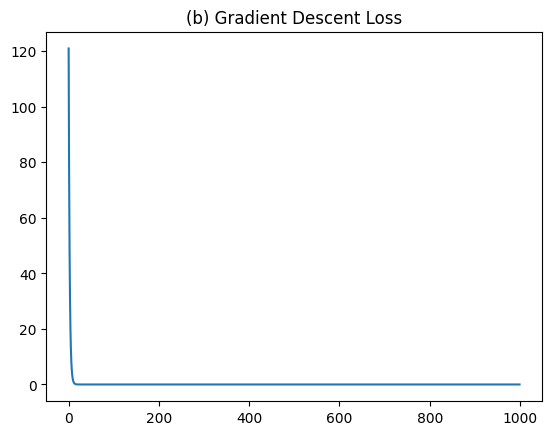

(b) Weights: [tensor([[1.0891, 0.1089]])]
(c)
x = [[20  2]
 [20  0]
 [ 0  2]
 [ 0  0]]
y = [[11]
 [11]
 [11]
 [11]]
w = [[0.36666667]
 [3.66666667]]


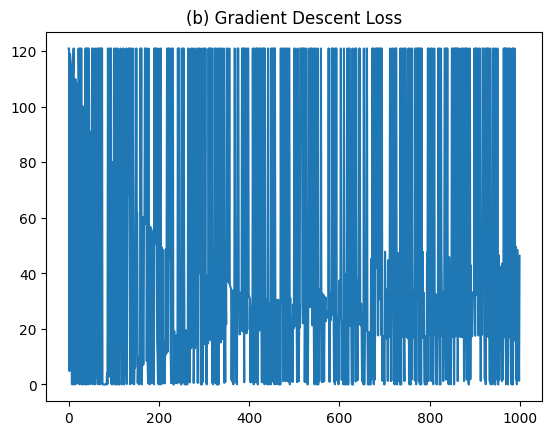

(b) Weights: [tensor([[0.4819, 3.5143]])]


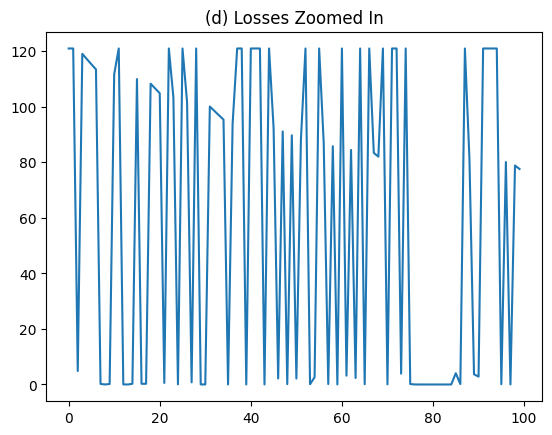

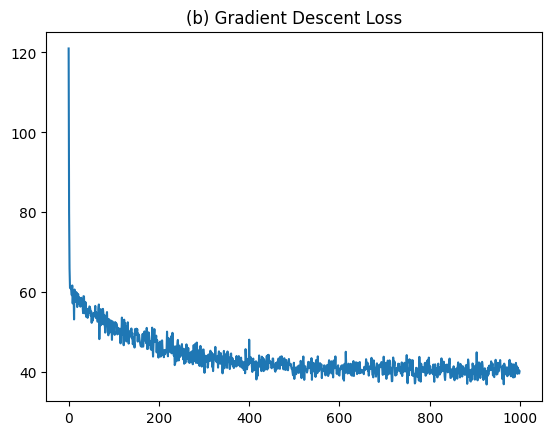

(b) Weights: [tensor([[0.3787, 3.4829]])]


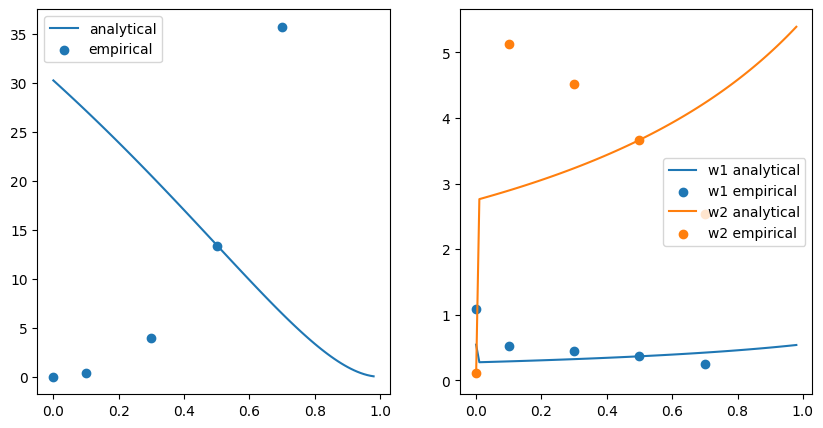

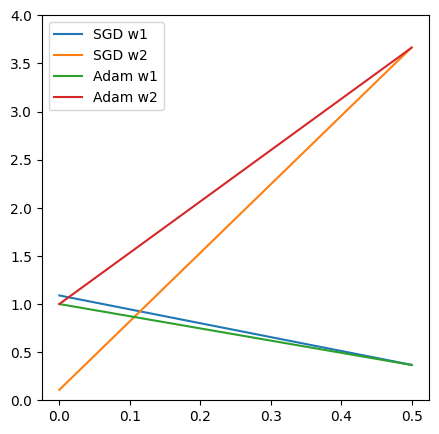

In [ ]:
# Imports
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# === (a) No Dropout, Least-Square ===
x = np.array([[10, 1]])
y = np.array([[11]])
w = np.linalg.pinv(x) @ y
print("(a)")
print("w =", w)

# === (b) No Dropout, Gradient Descent ===
def train_simple(net, lr=.001, batch_size=1, itrs=1000, plot=True, optim_class=torch.optim.SGD, x=None, y=None):
    optimizer = optim_class(net.parameters(), lr=lr)
    losses = []
    if x is None:
        x = torch.FloatTensor([[10, 1]])
        y = torch.FloatTensor([[11]])
    else:
        x = torch.FloatTensor(x)
        y = torch.FloatTensor(y)
    x = x.repeat(batch_size, 1)
    y = y.repeat(batch_size, 1)
    for i in range(itrs):
        y_hat = net(x)
        loss = torch.nn.MSELoss()(y_hat, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    if plot:
        plt.plot(losses)
        plt.title("(b) Gradient Descent Loss")
        plt.show()
        print_weights(net)
    return losses

def print_weights(net):
    print(f'(b) Weights: {list(net.state_dict().values())}')

net = nn.Sequential(torch.nn.Linear(2, 1, bias=False))
net.load_state_dict({k: v * 0 for k, v in net.state_dict().items()})
losses = train_simple(net)

# === (c) Dropout, Least-Square ===
x = np.array([[10, 1], [10, 0], [0, 1], [0, 0]]) * 2
y = np.array([[11], [11], [11], [11]])
w = np.linalg.pinv(x) @ y
print("(c)")
print("x =", x)
print("y =", y)
print("w =", w)

# === (d) Dropout, Gradient Descent ===
class Dropout(torch.nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p

    def forward(self, x):
        if self.training:
            mask = torch.bernoulli((1 - self.p) * torch.ones_like(x)) / (1 - self.p)
            return x * mask
        else:
            return x

def init_with_dropout(p):
    net = torch.nn.Sequential(
        Dropout(p),
        torch.nn.Linear(2, 1, bias=False)
    )
    net.load_state_dict({k: v * 0 for k, v in net.state_dict().items()})
    return net

net = init_with_dropout(0.5)
losses = train_simple(net)
plt.title("(d) Losses Zoomed In")
plt.plot(losses[:100])
plt.show()

# === (e) Dropout, Gradient Descent with Larger Batch Sizes ===
net = init_with_dropout(0.5)
losses = train_simple(net, batch_size=1024)

# === (f) [OPTIONAL] Sweep Dropout Rates ===
def weighted_least_squares(X, y, probs):
    S = np.diag(probs)
    XTX = X.T @ S @ X
    XTy = X.T @ S @ y
    return np.linalg.pinv(XTX) @ XTy

empirical_dropout_rates = [0, .1, .3, .5, .7]
analytical_dropout_rates = np.arange(0, .99, .01)
losses_empirical, losses_analytical = [], []
w1_empirical, w2_empirical, w1_analytical, w2_analytical = [], [], [], []

x_base = np.array([[10, 1]])
y_base = np.array([[11]])
data_points = [
    (np.array([[10, 1]]), 0.25),
    (np.array([[10, 0]]), 0.25),
    (np.array([[0, 1]]), 0.25),
    (np.array([[0, 0]]), 0.25)
]

for p in analytical_dropout_rates:
    keep_prob = 1 - p
    probs = [keep_prob**2, keep_prob*p, keep_prob*p, p**2]
    X = np.vstack([x for x, _ in data_points]) * 2
    Y = np.vstack([y_base for _ in data_points])
    w_analytic = weighted_least_squares(X, Y, probs)
    l_analytic = ((x_base @ w_analytic - y_base) ** 2).item()
    w1_analytical.append(w_analytic[0][0])
    w2_analytical.append(w_analytic[1][0])
    losses_analytical.append(l_analytic)

for p in empirical_dropout_rates:
    net = init_with_dropout(p)
    losses = train_simple(net, batch_size=1024, itrs=10000, plot=False)
    net.eval()
    losses_empirical.append(((net(torch.FloatTensor(x_base)) - torch.FloatTensor(y_base)) ** 2).item())
    w1_empirical.append(net.state_dict()['1.weight'][0][0].item())
    w2_empirical.append(net.state_dict()['1.weight'][0][1].item())

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(analytical_dropout_rates, losses_analytical, label='analytical')
plt.scatter(empirical_dropout_rates, losses_empirical, label='empirical')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(analytical_dropout_rates, w1_analytical, label='w1 analytical')
plt.scatter(empirical_dropout_rates, w1_empirical, label='w1 empirical')
plt.plot(analytical_dropout_rates, w2_analytical, label='w2 analytical')
plt.scatter(empirical_dropout_rates, w2_empirical, label='w2 empirical')
plt.legend()
plt.show()

# === (g) [OPTIONAL] Adam Optimizer ===
dropout_rates = [0, .5]
optim_classes = [torch.optim.SGD, torch.optim.Adam]
fig, axs = plt.subplots(figsize=(5, 5))

for optim_class in optim_classes:
    w1_list = []
    w2_list = []
    for p in dropout_rates:
        net = init_with_dropout(p).train()
        train_simple(net, batch_size=1024, itrs=10000, optim_class=optim_class, plot=False)
        net.eval()
        w1_list.append(net.state_dict()['1.weight'][0][0].item())
        w2_list.append(net.state_dict()['1.weight'][0][1].item())
    axs.plot(dropout_rates, w1_list, label=f'{optim_class.__name__} w1')
    axs.plot(dropout_rates, w2_list, label=f'{optim_class.__name__} w2')

axs.legend()
axs.set_ylim(0, 4)
plt.show()